# Семинар 2 + Домашнее задание: Анализ ChIP-seq данных FoxD3

**Бганцова  Полина Анатольевна, Б06-304в**


27.09.2026


## 1. Цель работы

Освоить полный пайплайн анализа ChIP-seq данных транскрипционного фактора FoxD3 на разных стадиях развития нервного гребня у *Danio rerio*: от контроля качества BAM до поиска пиков, визуализации и сравнения стадий.

**Задачи:**
- Провести QC и peak calling для стадии 14ss (семинар).
- Самостоятельно проанализировать стадии 75ep и 1-2ss (домашка).
- Сравнить binding landscape FoxD3 между четырьмя стадиями: 75ep, 1-2ss, 5-6ss, 14ss.
- Визуализировать результаты в IGV.

## 2. Данные

- **Стадии:** 75% epiboly (75ep), 1–2 somite stage (1-2ss), 5–6 somite stage (5-6ss), 14 somite stage (14ss).
- **Формат:** BAM-файлы ChIP и Input (paired-end).
- **Референс:** GRCz11 (геном зебрафиш, *Danio rerio*).
- **Для 5-6ss:** использован готовый пример преподавателя (teacher/5-6ss).
- **Инструменты:** samtools, deepTools (bamCoverage, bigwigCompare, computeMatrix, plotHeatmap, plotProfile), MACS3, bedtools.

## 3. Форматы файлов

| Формат | Что хранит | Text/Binary | Для чего использовали |
|--------|------------|-------------|----------------------|
| BAM | Выравнивания прочтений | Binary | Входные данные для MACS3 |
| BAI | Индекс BAM | Binary | Ускорение доступа к BAM |
| BigWig | Непрерывный сигнал | Binary | Визуализация coverage в IGV |
| BED | Геномные интервалы | Text | Саммиты пиков |
| narrowPeak | Пики ChIP-seq (BED6+4) | Text | Результаты MACS3 |
| peaks.xls | Подробный вывод MACS3 | Text | Анализ пиков |
| matrix.gz | Матрица для heatmap | Binary | deepTools |
| TSV | Табличные данные | Text | FRiP, метаданные |

**Разница BAM → BigWig → narrowPeak:**
- **BAM** — выравнивания (дискретные, привязаны к ридам).
- **BigWig** — непрерывный сигнал (coverage в бинах по геному).
- **narrowPeak** — дискретные обогащённые регионы (пики).

## 4. Методы

- **QC:** `samtools flagstat`
- **BigWig:** `bamCoverage` (нормализация CPM, binSize 10)
- **log2(ChIP/Input):** `bigwigCompare`
- **Поиск пиков:** `macs3 callpeak` (BAMPE, q=0.05 для семинара, q=0.01 для домашки)
- **FRiP:** `samtools view -c -L`
- **Heatmap/profile:** `computeMatrix`, `plotHeatmap`, `plotProfile`
- **Сравнение стадий:** `bedtools intersect`
- **Все вычисления — через SLURM** (кроме визуализации в IGV).

## 5. Семинар: анализ стадии 14ss

### 5.1. QC (samtools flagstat)
- **ChIP:** 41 553 880 ридов, 100% картировано, 100% правильно спарено, 0 дубликатов.
- **Input:** 27 794 668 ридов, 100% картировано, 100% правильно спарено, 0 дубликатов.

### 5.2. Peak calling (MACS3)
- **Число пиков:** 318.
- **FRiP:** 0.00189 (78 394 ридов в пиках / 41 553 880 всего).
- **Самый значимый пик:** NC_007126.7:35583495-35584004
  - signalValue: 24.9995
  - -log10(p): 330.35
  - -log10(q): 321.453
  - настоящий q-value: ~10^-321

### 5.3. Heatmap и average profile

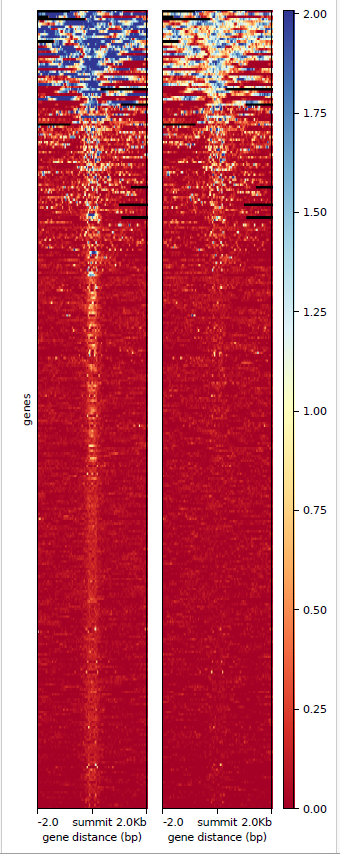

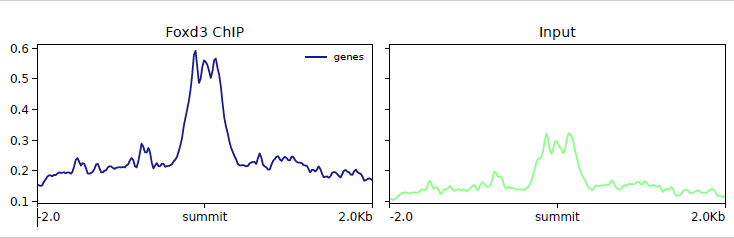

**Heatmap:** каждая строка — отдельный пик FoxD3. Видно чёткое обогащение ChIP в центре (вокруг summit), у Input сигнал более равномерный.

**Average profile:** FoxD3 ChIP показывает выраженный пик в центре (вокруг summit), Input — слабый и широкий сигнал. Это подтверждает успешное обогащение ChIP над фоном.

## 6. Сравнение стадий 14ss и 5-6ss (семинар)

### 6.1. Пересечение пиков (bedtools intersect)
- **Общие пики:** 53
- **Уникальные для 14ss:** 265
- **Уникальные для 5-6ss:** 786
- **Jaccard index:** 53 / (318 + 839 − 53) = 0.048

### 6.2. Вывод
Binding landscape FoxD3 сильно перестраивается между стадиями — общих пиков всего 53. Это согласуется с идеей смены функции FoxD3 (pioneer → repressor).

### 6.3. Сравнение самого значимого пика
| Параметр | 14ss | 5-6ss |
|----------|------|-------|
| Координаты | NC_007126.7:35583495-35584004 | NC_007117.7:32206483-32207024 |
| signalValue | 24.9995 | 21.1014 |
| -log10(q) | 321.453 | 163.701 |
| Настоящий q-value | ~10^-321 | ~10^-164 |

## 7. Домашка: анализ стадии 75% epiboly (75ep)

### 7.1. QC
- **ChIP:** 23 863 894 рида.
- **Input:** 39 931 858 ридов.

### 7.2. Peak calling (MACS3, q=0.01)
- **Число пиков:** 36.
- **FRiP:** 0.000172 (4 101 ридов в пиках / 23 863 894 всего).
- **Самый значимый пик:** NC_007113.7:33276014-33276551
  - signalValue: 21.7013
  - -log10(p): 109.261
  - -log10(q): 100.05
  - настоящий q-value: ~10^-100

### 7.3. Heatmap и average profile

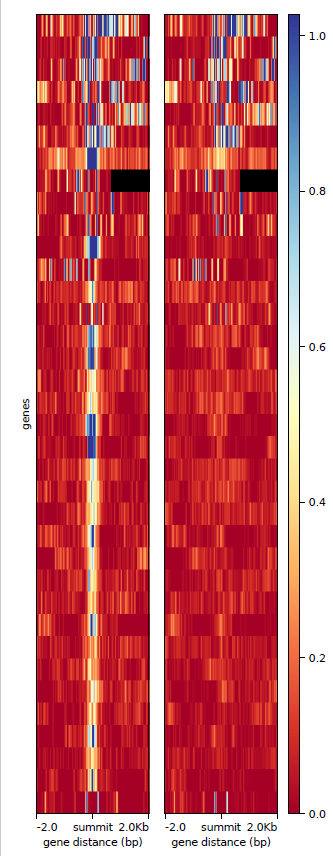

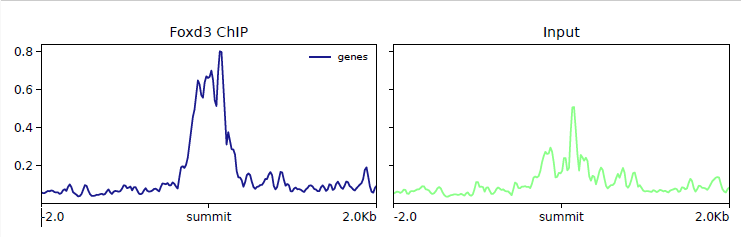

**Heatmap:** обогащение FoxD3 ChIP в центре (вокруг summit). Input показывает более равномерный фон.

**Average profile:** FoxD3 ChIP — выраженный пик в центре; Input — слабый и широкий сигнал. Обогащение присутствует, но слабее, чем на 14ss и 5-6ss (FRiP = 0.000172).

## 8. Домашка: анализ стадии 1–2 somite stage (1-2ss)

### 8.1. QC
- **ChIP:** 12 816 614 ридов.
- **Input:** 33 460 348 ридов.

### 8.2. Peak calling (MACS3, q=0.01)
- **Число пиков:** 40.
- **FRiP:** 0.000140 (1 799 ридов в пиках / 12 816 614 всего).
- **Самый значимый пик:** NC_007113.7:33276062-33276596
  - signalValue: 21.2286
  - -log10(p): 65.2724
  - -log10(q): 56.183
  - настоящий q-value: ~10^-56

### 8.3. Heatmap и average profile

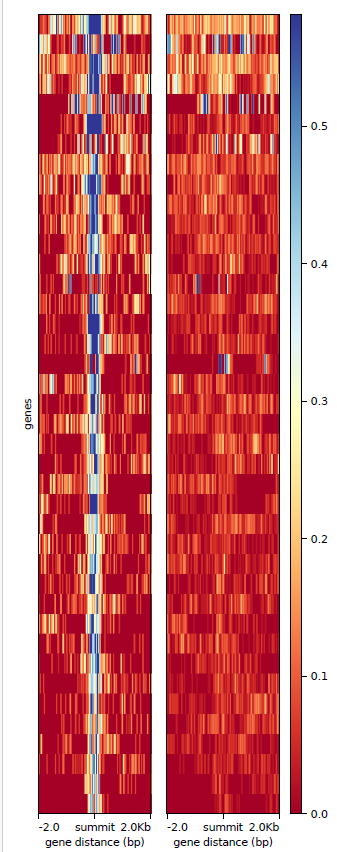

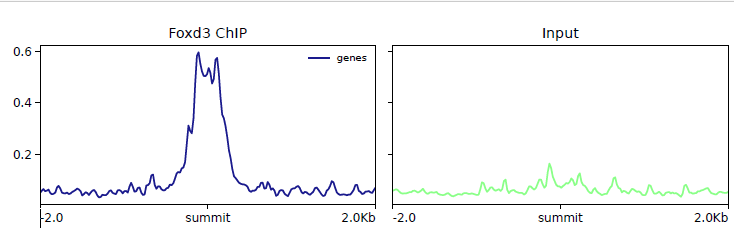

**Heatmap:** обогащение FoxD3 ChIP в центре (вокруг summit). Input показывает равномерный фон.

**Average profile:** FoxD3 ChIP — выраженный пик в центре; Input — слабый сигнал. Обогащение есть, но FRiP очень низкий (0.000140), что может указывать на слабое связывание FoxD3 на этой ранней стадии или на технические ограничения (мало ридов ChIP).

## 9. Сводная таблица четырёх стадий

| Stage | ChIP alignments | Input alignments | Peaks | FRiP | max -log10(q) |
|-------|-----------------|------------------|-------|------|---------------|
| 75ep  | 23 863 894 | 39 931 858 | 36 | 0.000172 | 100.05 |
| 1-2ss | 12 816 614 | 33 460 348 | 40 | 0.000140 | 56.18 |
| 5-6ss | 18 853 396 | — | 839 | 0.00236 | 163.70 |
| 14ss  | 41 553 880 | 27 794 668 | 318 | 0.00189 | 321.45 |

### Ответы на вопросы:
- **Больше всего пиков** — на стадии **5-6ss** (839).
- **Наиболее выраженный ChIP enrichment** (FRiP) — тоже на **5-6ss** (0.00236).
- **Разницу числа пиков нельзя объяснить только биологией:** глубина секвенирования, качество ChIP и эффективность антитела тоже влияют. У 75ep и 1-2ss меньше ридов, что могло ограничить чувствительность MACS3.

## 10. Биологическая интерпретация

1. **Остаётся ли FoxD3 binding landscape постоянным?** — Нет, он сильно меняется. Общих пиков между 14ss и 5-6ss всего 53 из 318/839.
2. **На какой стадии наиболее выраженный сигнал?** — По числу пиков: 5-6ss (839). По силе самого значимого пика: 14ss (-log10(q) = 321).
3. **Стабильные участки:** 53 общих пика (например, в районе гена *nfixa*).
4. **Появляющиеся/исчезающие участки:** 265 уникальных для 14ss и 786 для 5-6ss.
5. **Почему ChIP-seq не доказывает регуляцию?** — Пик означает связывание, но не эффект. Ближайший ген не обязательно мишень. Нужны данные о хроматине и экспрессии.
6. **Какие данные нужны для проверки функционального эффекта:** ATAC-seq (доступность хроматина), H3K27ac ChIP-seq (активность энхансеров), RNA-seq (экспрессия генов).

## 11. IGV — Screenshot 1: сильный пик на 5-6ss

**Координаты:** NC_007117.7:32,199,692-32,213,817

На скриншоте видно:
- ChIP (5-6ss) — сильный пик в районе 32,205,000.
- Input — ровный фон без пика.
- log2(ChIP/Input) — положительное обогащение.
- narrowPeak — вызванный пик foxd3_5-6ss_chip_peak_211.
- Рядом — ген *nfixa* (потенциальная мишень).

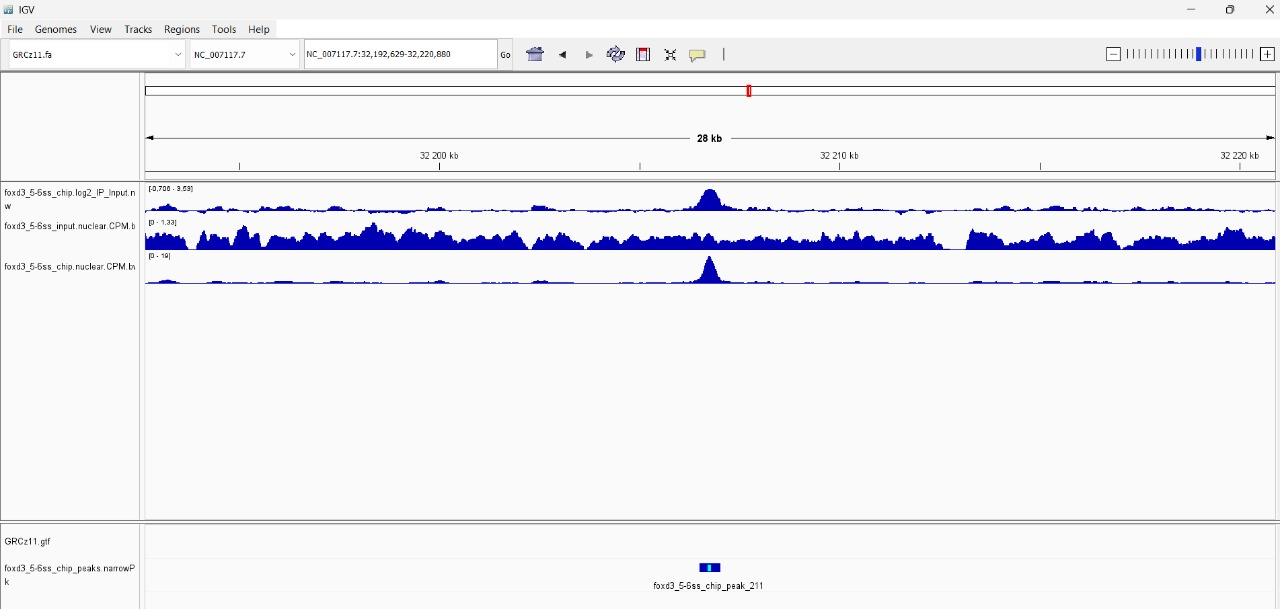

## 11. IGV — Screenshot 2: общий пик для 14ss и 5-6ss

**Координаты:** NC_007112.7:52,000,000-52,012,000

На скриншоте видно:
- ChIP (14ss) — пик в районе 52,006,000.
- ChIP (5-6ss) — пик в том же районе.
- narrowPeak — пики для обеих стадий.
- Рядом — ген *nfixa*.

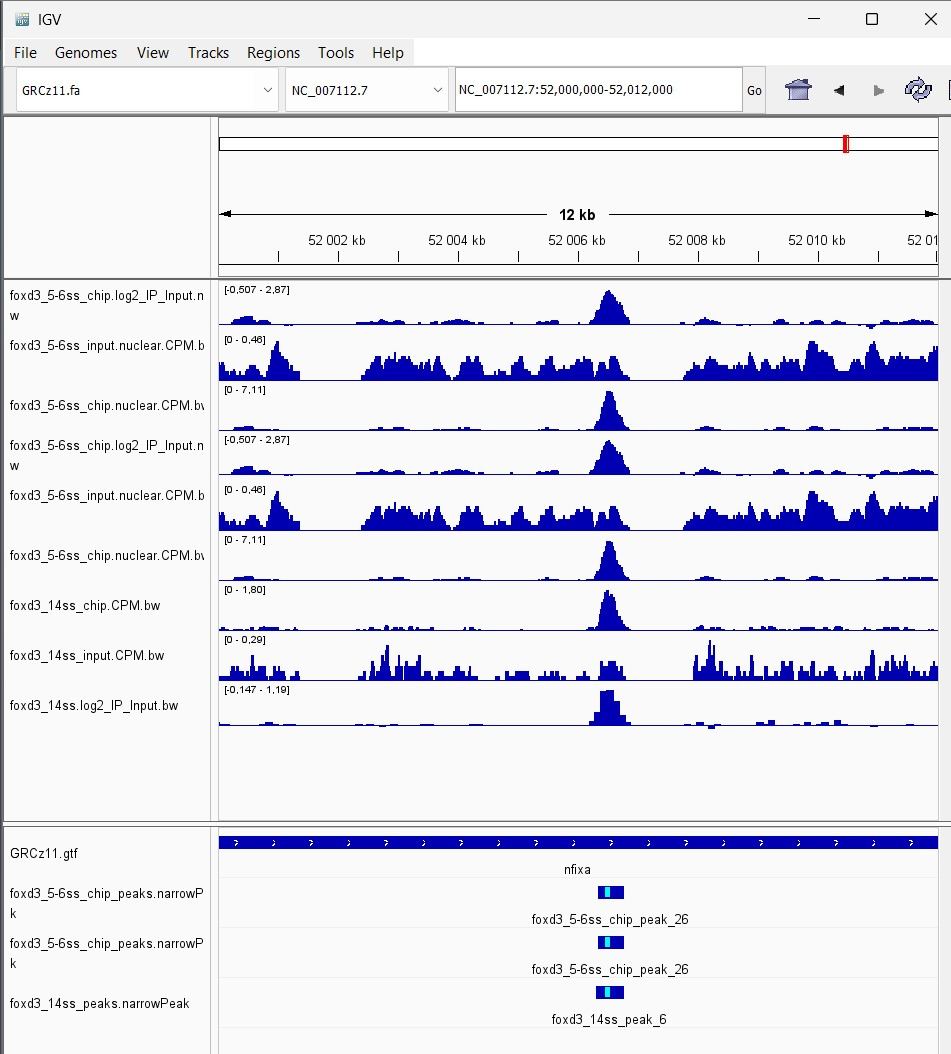

## 11. IGV — Screenshot 3: stage-specific пик 14ss

**Координаты:** NC_007112.7:839,000-849,000

На скриншоте видно:
- ChIP (14ss) — чёткий пик в районе 844,000.
- ChIP (5-6ss) — сигнал слабый/отсутствует.
- narrowPeak — пик foxd3_14ss_peak_2 есть только для 14ss.
- Это пример stage-specific связывания FoxD3.

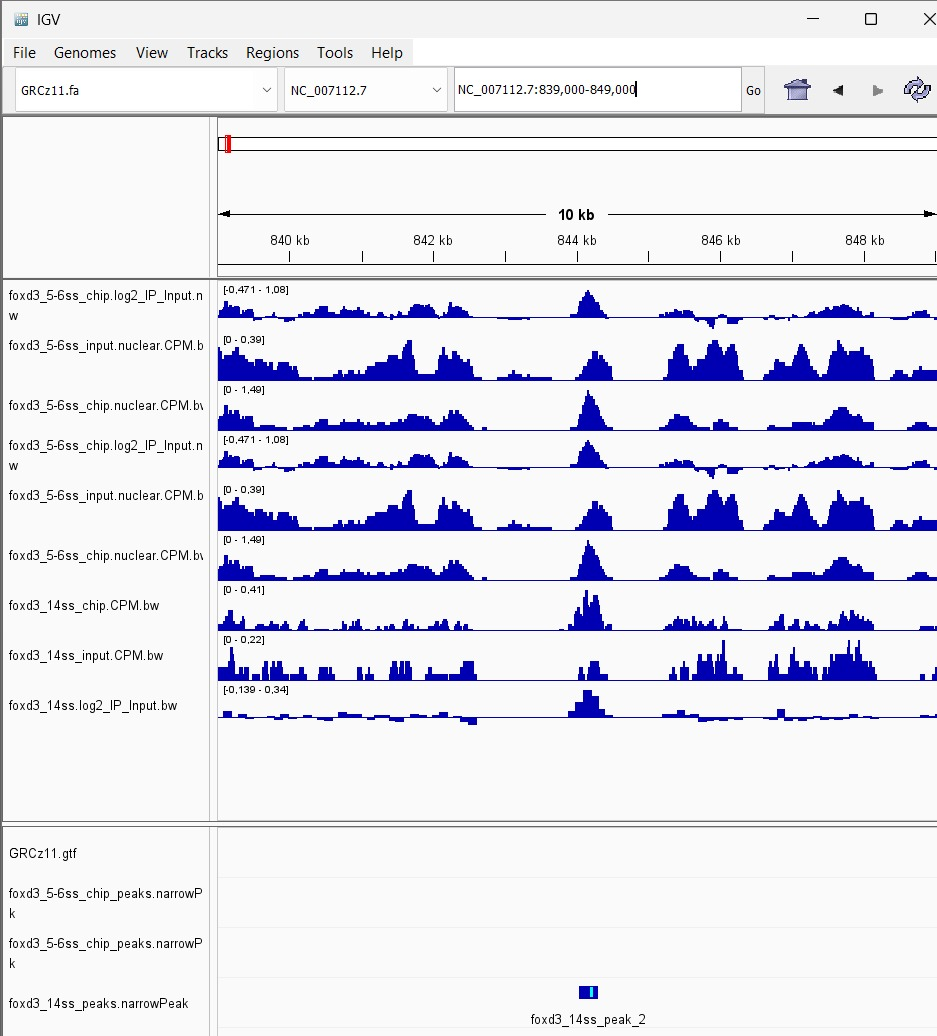

## 12. Вывод

В работе освоен полный пайплайн ChIP-seq: от QC BAM до поиска пиков и сравнения стадий. Показано, что FoxD3 связывается с разными участками на разных стадиях развития — общих пиков между 14ss и 5-6ss всего 53, что подтверждает смену его функции. Различия в числе пиков могут объясняться как биологией, так и техническими причинами (глубина секвенирования, качество ChIP).

## 13. Приложение - команды

In [ ]:
# QC
samtools flagstat data/14ss/foxd3_14ss_chip.nuclear.bam > logs/flagstat_chip.txt
samtools flagstat data/14ss/foxd3_14ss_input.nuclear.bam > logs/flagstat_input.txt

# BigWig
bamCoverage -b data/14ss/foxd3_14ss_chip.nuclear.bam -o results/signal/foxd3_14ss_chip.CPM.bw --normalizeUsing CPM --binSize 10 --numberOfProcessors 4
bamCoverage -b data/14ss/foxd3_14ss_input.nuclear.bam -o results/signal/foxd3_14ss_input.CPM.bw --normalizeUsing CPM --binSize 10 --numberOfProcessors 4

# log2(ChIP/Input)
bigwigCompare -b1 results/signal/foxd3_14ss_chip.CPM.bw -b2 results/signal/foxd3_14ss_input.CPM.bw --operation log2 --pseudocount 1 --binSize 100 --numberOfProcessors 4 -o results/signal/foxd3_14ss.log2_IP_Input.bw

# MACS3
macs3 callpeak -t data/14ss/foxd3_14ss_chip.nuclear.bam -c data/14ss/foxd3_14ss_input.nuclear.bam -f BAMPE -g 1.4e9 -n foxd3_14ss --outdir results/peaks/ -B -q 0.05

# FRiP
samtools view -c -L results/peaks/foxd3_14ss_peaks.narrowPeak data/14ss/foxd3_14ss_chip.nuclear.bam > logs/reads_in_peaks.txt

# Heatmap + profile
computeMatrix reference-point --referencePoint center -R results/peaks/foxd3_14ss_peaks.narrowPeak -S results/signal/foxd3_14ss_chip.CPM.bw results/signal/foxd3_14ss_input.CPM.bw -b 2000 -a 2000 --binSize 20 -o results/figures/foxd3_14ss.matrix.gz
plotHeatmap -m results/figures/foxd3_14ss.matrix.gz -out results/figures/foxd3_14ss.heatmap.pdf --samplesLabel "Foxd3 ChIP" "Input" --refPointLabel "summit"
plotProfile -m results/figures/foxd3_14ss.matrix.gz -out results/figures/foxd3_14ss.profile.pdf --samplesLabel "Foxd3 ChIP" "Input" --refPointLabel "summit"

# Сравнение стадий
bedtools intersect -a results/peaks/foxd3_14ss_peaks.narrowPeak -b teacher/5-6ss/peaks/foxd3_5-6ss_chip_peaks.narrowPeak -u > results/stage_comparison/shared_14ss_5-6ss.bed
bedtools intersect -a results/peaks/foxd3_14ss_peaks.narrowPeak -b teacher/5-6ss/peaks/foxd3_5-6ss_chip_peaks.narrowPeak -v > results/stage_comparison/only_14ss.bed